# Notebook 1: Data Loading & Visualization

**Goal:** Understand the raw Spine-Generic dataset — load NIfTI volumes, view slices, overlay labels, and confirm data integrity.

## What we'll cover:
1. Dataset structure (BIDS format)
2. Loading a single T2w MRI volume
3. Inspecting shape, spacing, orientation
4. Visualizing axial/sagittal/coronal slices
5. Loading and overlaying the spinal cord label
6. Git-annex stub detection
7. Multi-subject gallery

In [1]:
import os
import sys
from pathlib import Path

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Project root
PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

# Data root
DATA_ROOT = PROJECT_ROOT / "data" / "spine-generic"
LABELS_ROOT = DATA_ROOT / "derivatives" / "labels"

print(f"Project root: {PROJECT_ROOT.resolve()}")
print(f"Data root:    {DATA_ROOT.resolve()}")
print(f"Data exists:  {DATA_ROOT.exists()}")

Project root: /home/l091835/cns
Data root:    /home/l091835/cns/data/spine-generic
Data exists:  True


## 1. Dataset Structure

The Spine-Generic dataset follows **BIDS** (Brain Imaging Data Structure) format.  
Our local copy lives at `data/spine-generic/`:

```
data/spine-generic/
├── participants.tsv                              # Subject demographics (age, sex, site)
├── participants.json                             # Column descriptions
├── dataset_description.json                      # BIDS metadata
├── exclude.yml                                   # Subjects to exclude
├── sourcedata/                                   # Raw scanner data
├── code/                                         # Processing scripts from authors
│
├── sub-amu01/                                    # One directory per subject
│   └── anat/
│       ├── sub-amu01_T2w.nii.gz                  ← INPUT (T2-weighted MRI)
│       ├── sub-amu01_T2w.json                    # Acquisition parameters
│       ├── sub-amu01_T1w.nii.gz                  # Other contrasts (not used)
│       ├── sub-amu01_T2star.nii.gz
│       ├── sub-amu01_flip-1_mt-on_MTS.nii.gz
│       └── ...
│
├── derivatives/
│   ├── labels/                                   ← SEGMENTATION LABELS
│   │   └── sub-amu01/anat/
│   │       ├── sub-amu01_T2w_label-SC_seg.nii.gz          ← SPINAL CORD (binary, our target)
│   │       ├── sub-amu01_T2w_label-canal_seg.nii.gz       # Spinal canal
│   │       ├── sub-amu01_T2w_label-discs_dlabel.nii.gz    # Intervertebral discs
│   │       ├── sub-amu01_T2w_label-rootlets_dseg.nii.gz   # Nerve rootlets (C2-C8)
│   │       ├── sub-amu01_T2w_label-spine_dseg.nii.gz      # Full spine
│   │       └── ... (also T1w, T2star, MTS labels)
│   ├── labels_softseg/                           # Soft (probabilistic) segmentations
│   └── labels_softseg_bin/                       # Binarized soft segmentations
│
├── sub-amu02/
├── sub-balgrist01/
├── sub-beijingGE01/
├── ...
└── sub-vuiisIngenia05/                           # 267 subjects total, 42+ sites
```

**Key points:**
- Images and labels are in **separate** trees (labels under `derivatives/labels/`)
- Multiple contrasts per subject — we only use **T2w**
- Multiple label types — we use **`label-SC_seg`** (spinal cord binary mask)
- Subject naming: `sub-<site><number>` (e.g., `sub-amu01` → site "amu", subject 1)

In [2]:
# Discover all subject directories
subject_dirs = sorted([d for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith("sub-")])
print(f"Total subjects found: {len(subject_dirs)}")
print(f"\nFirst 10 subjects: {[d.name for d in subject_dirs[:10]]}")
print(f"Last 5 subjects:   {[d.name for d in subject_dirs[-5:]]}")

Total subjects found: 267

First 10 subjects: ['sub-amu01', 'sub-amu02', 'sub-amu03', 'sub-amu04', 'sub-amu05', 'sub-balgrist01', 'sub-balgrist02', 'sub-balgrist03', 'sub-balgrist04', 'sub-balgrist05']
Last 5 subjects:   ['sub-vuiisIngenia02', 'sub-vuiisIngenia03', 'sub-vuiisIngenia04', 'sub-vuiisIngenia05', 'sub-vuiisIngenia06']


In [3]:
# Check git-annex status: which files are real vs pointer stubs?
def check_file_status(path: Path) -> str:
    """Check if a file is real data or a git-annex pointer stub."""
    if not path.exists():
        return "MISSING"
    size = path.stat().st_size
    if size < 1000:
        return f"ANNEX STUB ({size} bytes)"
    return f"REAL ({size / 1e6:.1f} MB)"

# Check a few subjects
print("=" * 70)
print(f"{'Subject':<20} {'Image Status':<25} {'Label Status':<25}")
print("=" * 70)

for sub_dir in subject_dirs[:15]:
    sub_id = sub_dir.name
    img_path = sub_dir / "anat" / f"{sub_id}_T2w.nii.gz"
    lbl_path = LABELS_ROOT / sub_id / "anat" / f"{sub_id}_T2w_label-SC_seg.nii.gz"
    print(f"{sub_id:<20} {check_file_status(img_path):<25} {check_file_status(lbl_path):<25}")

Subject              Image Status              Label Status             
sub-amu01            REAL (8.9 MB)             REAL (0.0 MB)            
sub-amu02            REAL (9.3 MB)             REAL (0.0 MB)            
sub-amu03            REAL (12.6 MB)            REAL (0.0 MB)            
sub-amu04            REAL (14.0 MB)            REAL (0.0 MB)            
sub-amu05            REAL (19.7 MB)            REAL (0.0 MB)            
sub-balgrist01       REAL (22.9 MB)            REAL (0.0 MB)            
sub-balgrist02       REAL (20.9 MB)            REAL (0.0 MB)            
sub-balgrist03       REAL (11.3 MB)            REAL (0.0 MB)            
sub-balgrist04       REAL (17.9 MB)            REAL (0.0 MB)            
sub-balgrist05       REAL (10.7 MB)            REAL (0.0 MB)            
sub-balgrist06       REAL (10.2 MB)            REAL (0.0 MB)            
sub-barcelona01      REAL (18.7 MB)            REAL (0.0 MB)            
sub-barcelona02      REAL (12.2 MB)            REAL

## 2. Load a Single T2w MRI Volume

T2w = T2-weighted MRI. In T2w images:
- **CSF (fluid) appears BRIGHT** (hyperintense)
- **Spinal cord appears DARK** (hypointense)
- This contrast is ideal for segmenting fluid spaces around the cord

In [4]:
# Pick the first subject with real data
def find_first_real_subject(data_root, labels_root, min_size=1000):
    """Find the first subject where both image and label are real files."""
    for sub_dir in sorted(data_root.iterdir()):
        if not sub_dir.is_dir() or not sub_dir.name.startswith("sub-"):
            continue
        sub_id = sub_dir.name
        img = sub_dir / "anat" / f"{sub_id}_T2w.nii.gz"
        lbl = labels_root / sub_id / "anat" / f"{sub_id}_T2w_label-SC_seg.nii.gz"
        if img.exists() and lbl.exists():
            if img.stat().st_size > min_size and lbl.stat().st_size > min_size:
                return sub_id, img, lbl
    return None, None, None

subject_id, image_path, label_path = find_first_real_subject(DATA_ROOT, LABELS_ROOT)

if subject_id is None:
    print("⚠️  No subjects with real data found!")
    print("   Labels are probably git-annex stubs.")
    print("   Run: bash scripts/setup_data.sh")
    print("")
    print("   Falling back to image-only visualization...")
    # Just load an image without label
    for sub_dir in sorted(DATA_ROOT.iterdir()):
        if sub_dir.is_dir() and sub_dir.name.startswith("sub-"):
            sub_id = sub_dir.name
            img = sub_dir / "anat" / f"{sub_id}_T2w.nii.gz"
            if img.exists() and img.stat().st_size > 1000:
                subject_id = sub_id
                image_path = img
                label_path = None
                break

print(f"Subject: {subject_id}")
print(f"Image:   {image_path}")
print(f"Label:   {label_path}")

Subject: sub-amu01
Image:   ../data/spine-generic/sub-amu01/anat/sub-amu01_T2w.nii.gz
Label:   ../data/spine-generic/derivatives/labels/sub-amu01/anat/sub-amu01_T2w_label-SC_seg.nii.gz


In [5]:
# Load the NIfTI image
img_nii = nib.load(str(image_path))
img_data = np.asarray(img_nii.dataobj).astype(np.float32)

print("=== T2w MRI Volume ===")
print(f"Shape:       {img_data.shape}  (typically: Sagittal × Coronal × Axial)")
print(f"Data type:   {img_nii.header.get_data_dtype()}")
print(f"Voxel size:  {img_nii.header.get_zooms()[:3]} mm")
print(f"Orientation: {nib.aff2axcodes(img_nii.affine)}")
print(f"Affine:\n{img_nii.affine}")
print(f"\nIntensity range: [{img_data.min():.1f}, {img_data.max():.1f}]")
print(f"Mean intensity:  {img_data.mean():.1f}")
print(f"Nonzero voxels:  {(img_data > 0).sum()} / {img_data.size} ({100*(img_data>0).sum()/img_data.size:.1f}%)")

=== T2w MRI Volume ===
Shape:       (64, 320, 320)  (typically: Sagittal × Coronal × Axial)
Data type:   float64
Voxel size:  (0.80000114, 0.8, 0.8) mm
Orientation: ('L', 'A', 'S')
Affine:
[[  -0.80000114    0.            0.           19.14673424]
 [   0.            0.80000001    0.         -114.55900574]
 [   0.            0.            0.80000001 -105.61312866]
 [   0.            0.            0.            1.        ]]

Intensity range: [0.0, 2234.0]
Mean intensity:  101.5
Nonzero voxels:  4423253 / 6553600 (67.5%)


## 3. Visualize Orthogonal Slices

Standard anatomical planes:
- **Axial** (transverse): looking down from above — shows cross-section of cord
- **Sagittal**: side view — shows length of cord
- **Coronal**: front view

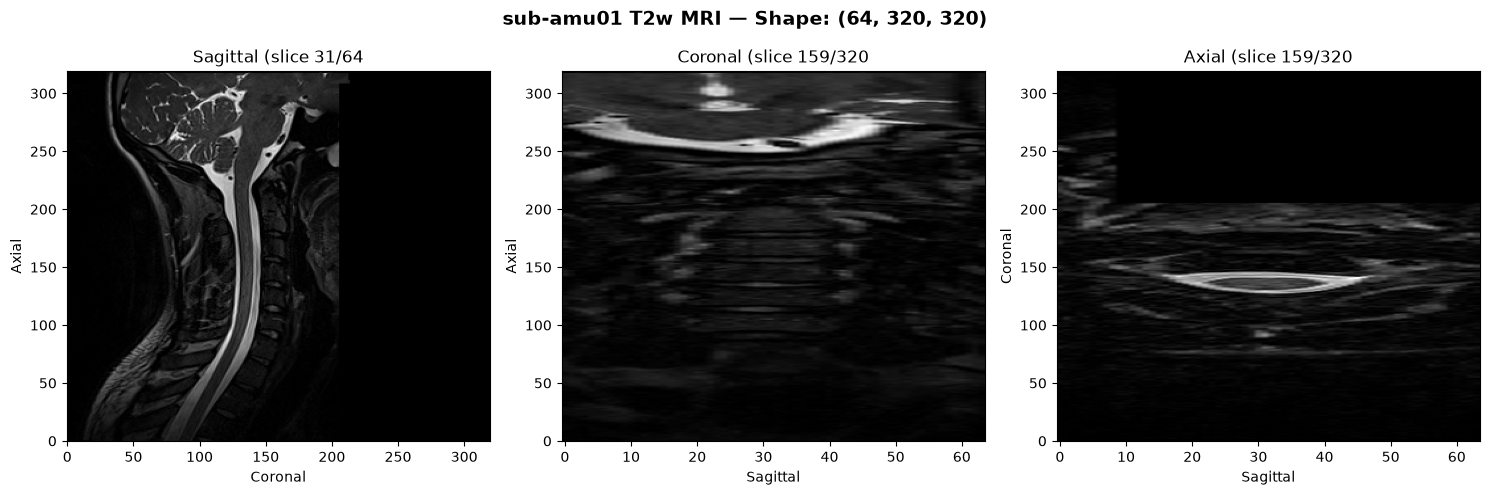

In [6]:
def show_orthogonal_slices(volume, title="MRI Volume", slice_fracs=(0.5, 0.5, 0.5)):
    """Display axial, sagittal, and coronal slices at given fractional positions."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Compute slice indices from fractions
    s = [int(f * (volume.shape[i] - 1)) for i, f in enumerate(slice_fracs)]
    
    # Sagittal (dim 0)
    axes[0].imshow(volume[s[0], :, :].T, cmap='gray', origin='lower', aspect='auto')
    axes[0].set_title(f'Sagittal (slice {s[0]}/{volume.shape[0]}')
    axes[0].set_xlabel('Coronal')
    axes[0].set_ylabel('Axial')
    
    # Coronal (dim 1)
    axes[1].imshow(volume[:, s[1], :].T, cmap='gray', origin='lower', aspect='auto')
    axes[1].set_title(f'Coronal (slice {s[1]}/{volume.shape[1]}')
    axes[1].set_xlabel('Sagittal')
    axes[1].set_ylabel('Axial')
    
    # Axial (dim 2)
    axes[2].imshow(volume[:, :, s[2]].T, cmap='gray', origin='lower', aspect='auto')
    axes[2].set_title(f'Axial (slice {s[2]}/{volume.shape[2]}')
    axes[2].set_xlabel('Sagittal')
    axes[2].set_ylabel('Coronal')
    
    fig.suptitle(f'{title} — Shape: {volume.shape}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_orthogonal_slices(img_data, title=f"{subject_id} T2w MRI")

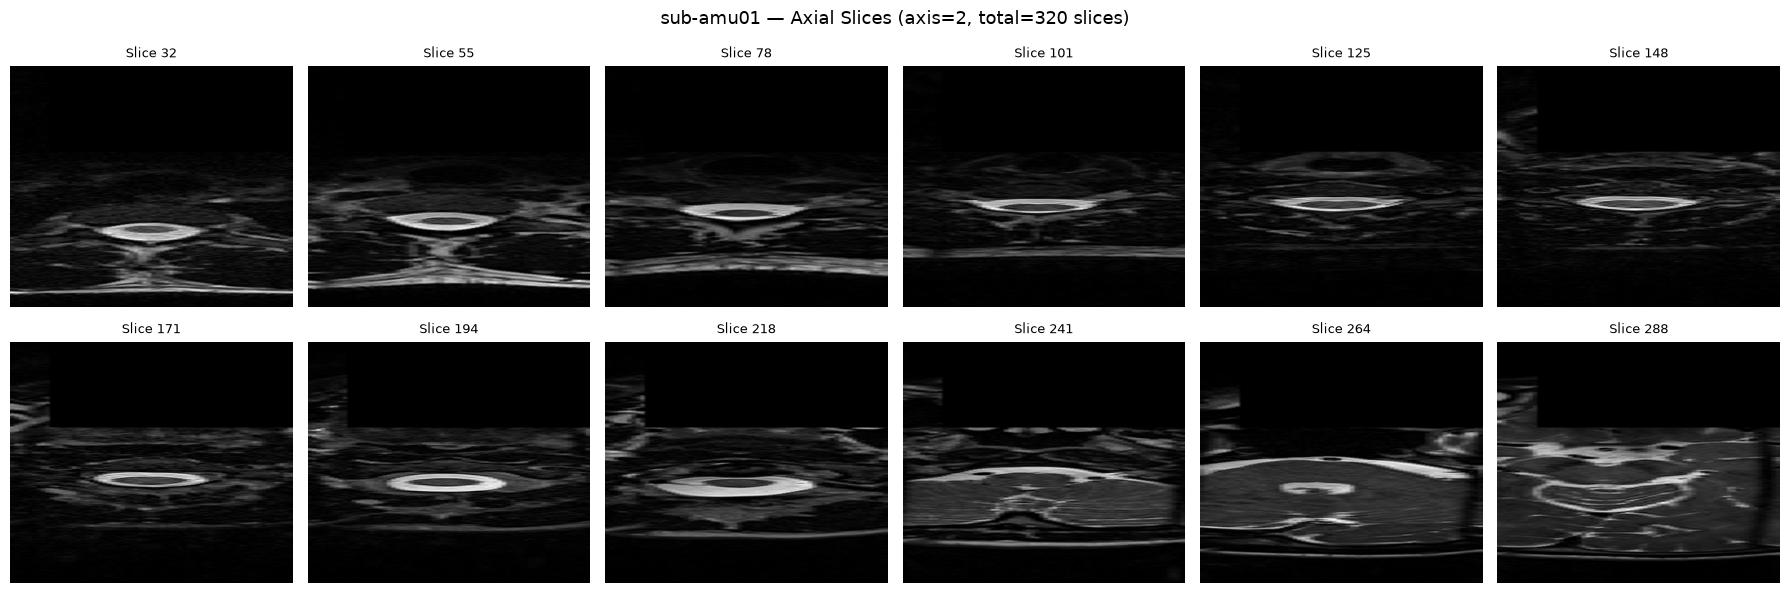

In [7]:
# Show multiple axial slices through the volume (like scrolling through)
def show_slice_gallery(volume, axis=2, n_slices=12, title="Axial Slice Gallery"):
    """Show evenly-spaced slices along one axis."""
    n_total = volume.shape[axis]
    indices = np.linspace(0.1 * n_total, 0.9 * n_total, n_slices, dtype=int)
    
    rows = 2
    cols = n_slices // rows
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    
    for idx, ax in zip(indices, axes.flat):
        if axis == 0:
            sl = volume[idx, :, :].T
        elif axis == 1:
            sl = volume[:, idx, :].T
        else:
            sl = volume[:, :, idx].T
        ax.imshow(sl, cmap='gray', origin='lower', aspect='auto')
        ax.set_title(f'Slice {idx}', fontsize=9)
        ax.axis('off')
    
    fig.suptitle(f"{title} (axis={axis}, total={n_total} slices)", fontsize=13)
    plt.tight_layout()
    plt.show()

show_slice_gallery(img_data, axis=2, n_slices=12, title=f"{subject_id} — Axial Slices")

## 4. Load and Overlay Spinal Cord Label

The label is a **binary mask**: 1 = spinal cord, 0 = background.  
Located at: `derivatives/labels/sub-*/anat/*_T2w_label-SC_seg.nii.gz`

In [8]:
if label_path is not None and label_path.exists() and label_path.stat().st_size > 1000:
    lbl_nii = nib.load(str(label_path))
    lbl_data = np.asarray(lbl_nii.dataobj).astype(np.uint8)
    
    print("=== Spinal Cord Label ===")
    print(f"Shape:        {lbl_data.shape}")
    print(f"Unique values: {np.unique(lbl_data)}")
    print(f"Voxel size:   {lbl_nii.header.get_zooms()[:3]} mm")
    print(f"Orientation:  {nib.aff2axcodes(lbl_nii.affine)}")
    print(f"\nSpinal cord voxels: {(lbl_data > 0).sum()} / {lbl_data.size}")
    print(f"Fraction:           {100*(lbl_data > 0).sum()/lbl_data.size:.3f}%")
    
    # Shapes should match
    assert img_data.shape == lbl_data.shape, f"Shape mismatch! img={img_data.shape}, lbl={lbl_data.shape}"
    print(f"\n✓ Image and label shapes match: {img_data.shape}")
else:
    lbl_data = None
    print("⚠️  No real label available. Run: bash scripts/setup_data.sh")
    print("   This copies label files from .backup/ to data/ directory.")

=== Spinal Cord Label ===
Shape:        (64, 320, 320)
Unique values: [0 1]
Voxel size:   (0.80000114, 0.8, 0.8) mm
Orientation:  ('L', 'A', 'S')

Spinal cord voxels: 25325 / 6553600
Fraction:           0.386%

✓ Image and label shapes match: (64, 320, 320)


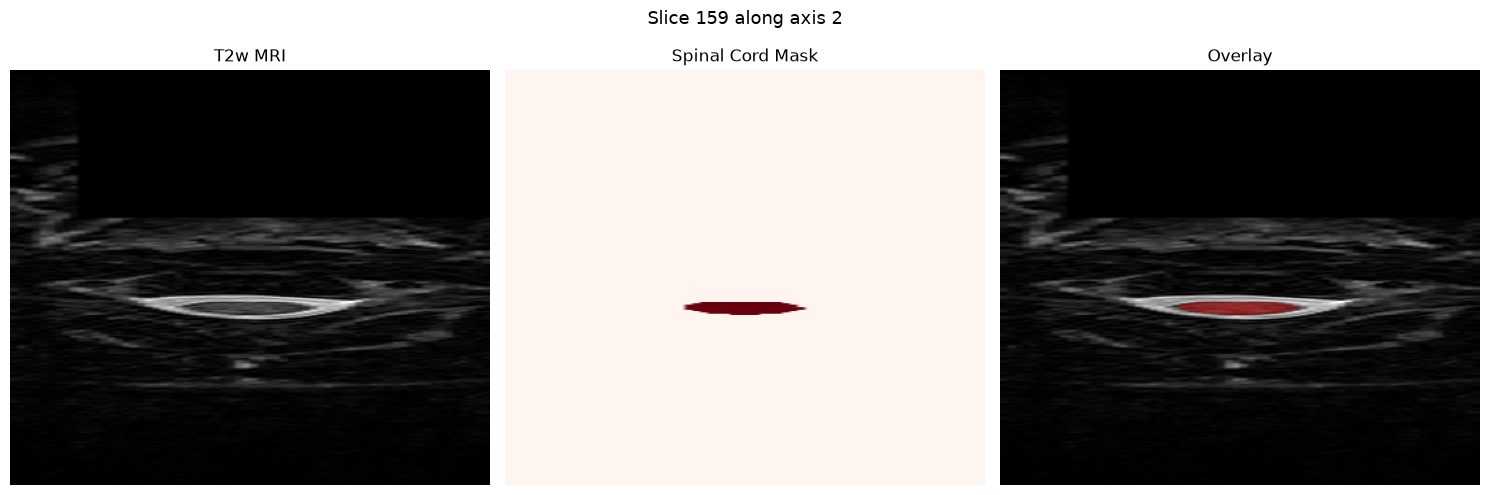

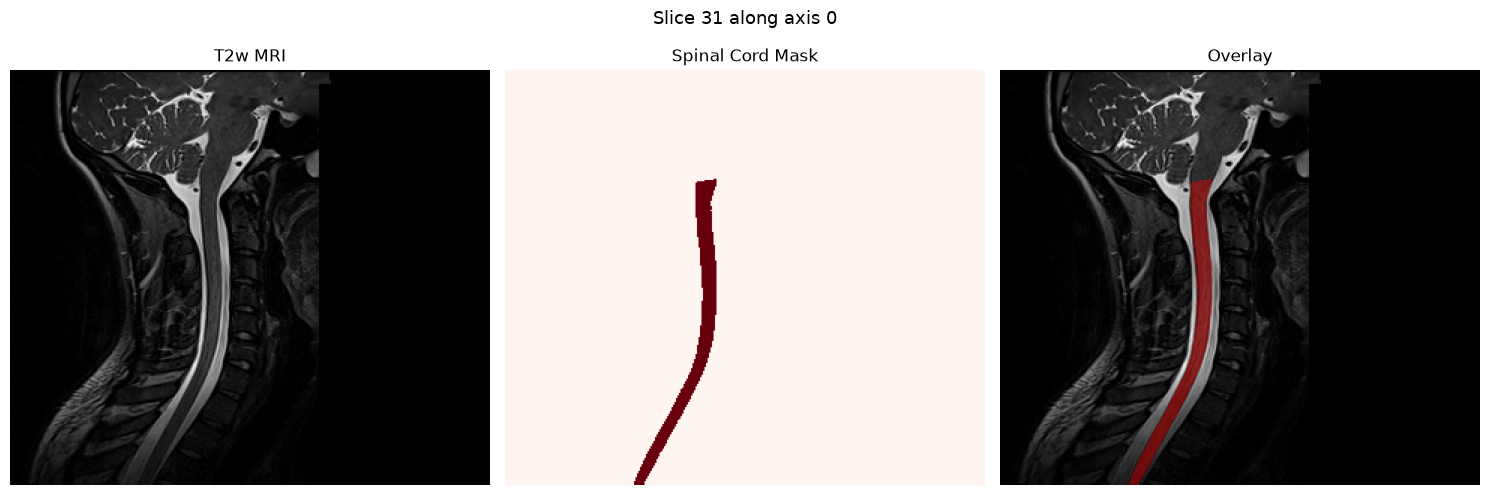

In [9]:
def show_overlay(image, label, axis=2, slice_frac=0.5, alpha=0.4):
    """Show MRI with segmentation label overlay."""
    idx = int(slice_frac * (image.shape[axis] - 1))
    
    if axis == 0:
        img_slice = image[idx, :, :].T
        lbl_slice = label[idx, :, :].T if label is not None else None
    elif axis == 1:
        img_slice = image[:, idx, :].T
        lbl_slice = label[:, idx, :].T if label is not None else None
    else:
        img_slice = image[:, :, idx].T
        lbl_slice = label[:, :, idx].T if label is not None else None
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Image only
    axes[0].imshow(img_slice, cmap='gray', origin='lower', aspect='auto')
    axes[0].set_title('T2w MRI')
    axes[0].axis('off')
    
    # Label only
    if lbl_slice is not None:
        axes[1].imshow(lbl_slice, cmap='Reds', origin='lower', aspect='auto')
        axes[1].set_title('Spinal Cord Mask')
    else:
        axes[1].text(0.5, 0.5, 'No label\navailable', ha='center', va='center', fontsize=14)
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(img_slice, cmap='gray', origin='lower', aspect='auto')
    if lbl_slice is not None:
        mask = np.ma.masked_where(lbl_slice == 0, lbl_slice)
        axes[2].imshow(mask, cmap='autumn', alpha=alpha, origin='lower', aspect='auto')
    axes[2].set_title('Overlay')
    axes[2].axis('off')
    
    plt.suptitle(f'Slice {idx} along axis {axis}', fontsize=13)
    plt.tight_layout()
    plt.show()

# Show middle axial slice
show_overlay(img_data, lbl_data, axis=2, slice_frac=0.5)
# Show sagittal view
show_overlay(img_data, lbl_data, axis=0, slice_frac=0.5)

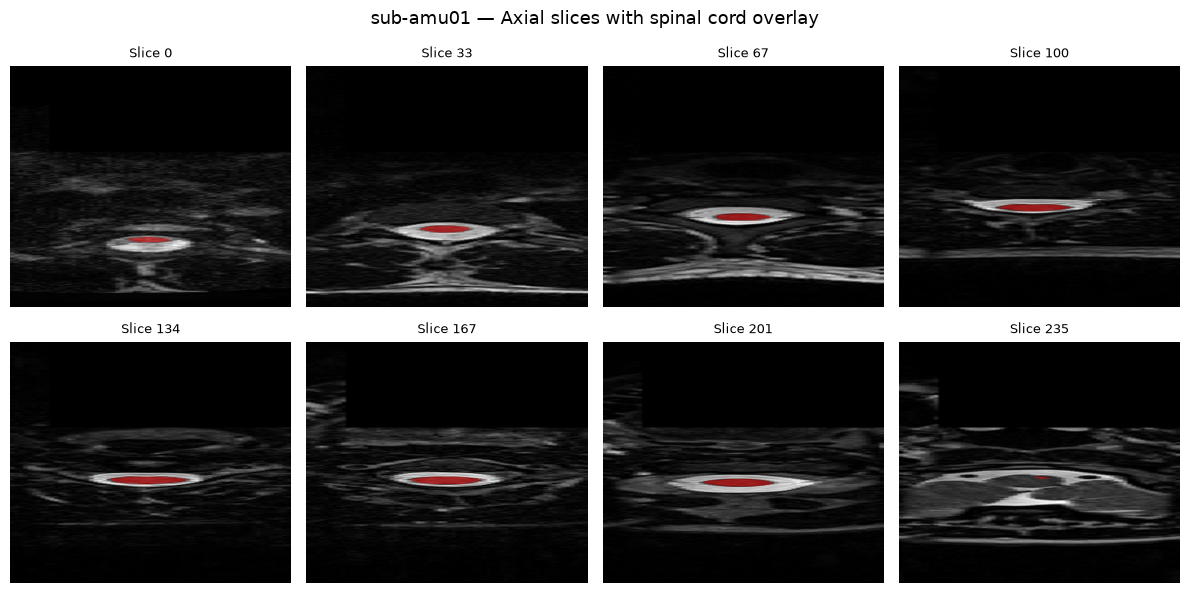

Label present in slices 0 to 235 (of 320 total)


In [10]:
def show_overlay_gallery(image, label, axis=2, n_slices=8):
    """Show multiple slices with label overlay."""
    if label is None:
        print("No label available for overlay gallery.")
        return
    
    # Find slices where the label has content
    label_sum = label.sum(axis=tuple(i for i in range(3) if i != axis))
    nonzero_slices = np.where(label_sum > 0)[0]
    
    if len(nonzero_slices) == 0:
        print("Label is empty!")
        return
    
    # Pick evenly-spaced slices from the range with label content
    indices = np.linspace(nonzero_slices[0], nonzero_slices[-1], n_slices, dtype=int)
    
    fig, axes = plt.subplots(2, n_slices // 2, figsize=(3 * n_slices // 2, 6))
    
    for idx, ax in zip(indices, axes.flat):
        if axis == 2:
            img_sl = image[:, :, idx].T
            lbl_sl = label[:, :, idx].T
        elif axis == 0:
            img_sl = image[idx, :, :].T
            lbl_sl = label[idx, :, :].T
        else:
            img_sl = image[:, idx, :].T
            lbl_sl = label[:, idx, :].T
        
        ax.imshow(img_sl, cmap='gray', origin='lower', aspect='auto')
        mask = np.ma.masked_where(lbl_sl == 0, lbl_sl)
        ax.imshow(mask, cmap='autumn', alpha=0.5, origin='lower', aspect='auto')
        ax.set_title(f'Slice {idx}', fontsize=9)
        ax.axis('off')
    
    fig.suptitle(f'{subject_id} — Axial slices with spinal cord overlay', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print(f"Label present in slices {nonzero_slices[0]} to {nonzero_slices[-1]} (of {image.shape[axis]} total)")

show_overlay_gallery(img_data, lbl_data, axis=2, n_slices=8)

## 5. Intensity Histogram

Understanding the intensity distribution helps us choose normalization strategies.

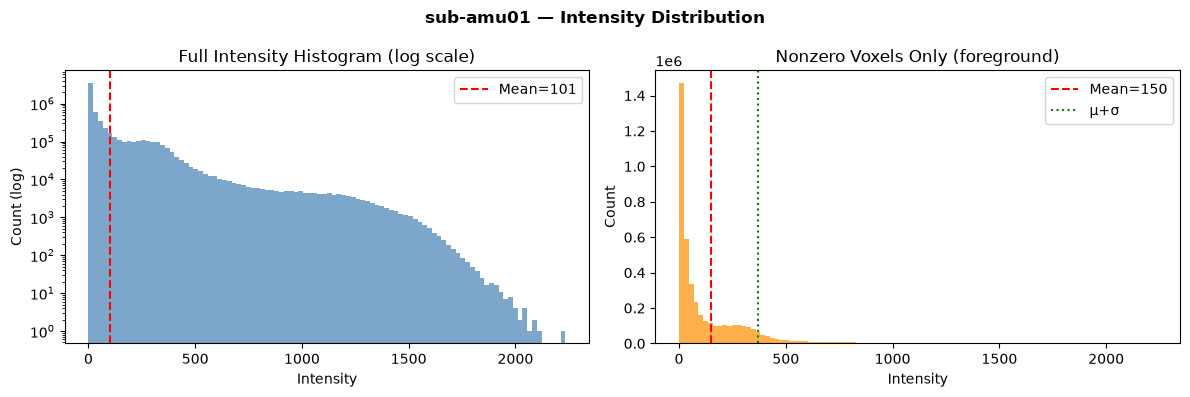

Nonzero stats: mean=150.3, std=220.7, median=54.0, p5=4.0, p95=545.0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Full histogram
axes[0].hist(img_data.flatten(), bins=100, color='steelblue', alpha=0.7, log=True)
axes[0].set_title('Full Intensity Histogram (log scale)')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Count (log)')
axes[0].axvline(img_data.mean(), color='red', linestyle='--', label=f'Mean={img_data.mean():.0f}')
axes[0].legend()

# Nonzero only (foreground)
nonzero = img_data[img_data > 0]
axes[1].hist(nonzero.flatten(), bins=100, color='darkorange', alpha=0.7)
axes[1].set_title('Nonzero Voxels Only (foreground)')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Count')
axes[1].axvline(nonzero.mean(), color='red', linestyle='--', label=f'Mean={nonzero.mean():.0f}')
axes[1].axvline(nonzero.std() + nonzero.mean(), color='green', linestyle=':', label=f'μ+σ')
axes[1].legend()

plt.suptitle(f'{subject_id} — Intensity Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Nonzero stats: mean={nonzero.mean():.1f}, std={nonzero.std():.1f}, "
      f"median={np.median(nonzero):.1f}, p5={np.percentile(nonzero, 5):.1f}, p95={np.percentile(nonzero, 95):.1f}")

## 6. Multi-Subject Comparison

Compare the same axial slice across different subjects/sites to see variability.

In [12]:
def load_all_available_subjects(data_root, labels_root, max_subjects=10, min_size=1000):
    """Load all subjects with real image data."""
    subjects = []
    for sub_dir in sorted(data_root.iterdir()):
        if not sub_dir.is_dir() or not sub_dir.name.startswith("sub-"):
            continue
        sub_id = sub_dir.name
        img_path = sub_dir / "anat" / f"{sub_id}_T2w.nii.gz"
        lbl_path = labels_root / sub_id / "anat" / f"{sub_id}_T2w_label-SC_seg.nii.gz"
        
        if img_path.exists() and img_path.stat().st_size > min_size:
            has_label = lbl_path.exists() and lbl_path.stat().st_size > min_size
            subjects.append({
                "id": sub_id,
                "image_path": img_path,
                "label_path": lbl_path if has_label else None,
            })
        if len(subjects) >= max_subjects:
            break
    return subjects

available = load_all_available_subjects(DATA_ROOT, LABELS_ROOT, max_subjects=8)
print(f"Subjects with real image data: {len(available)}")
for s in available:
    lbl_status = "✓" if s['label_path'] else "✗"
    print(f"  {s['id']:<20} label: {lbl_status}")

Subjects with real image data: 8
  sub-amu01            label: ✓
  sub-amu02            label: ✓
  sub-amu03            label: ✓
  sub-amu04            label: ✓
  sub-amu05            label: ✓
  sub-balgrist01       label: ✓
  sub-balgrist02       label: ✓
  sub-balgrist03       label: ✓


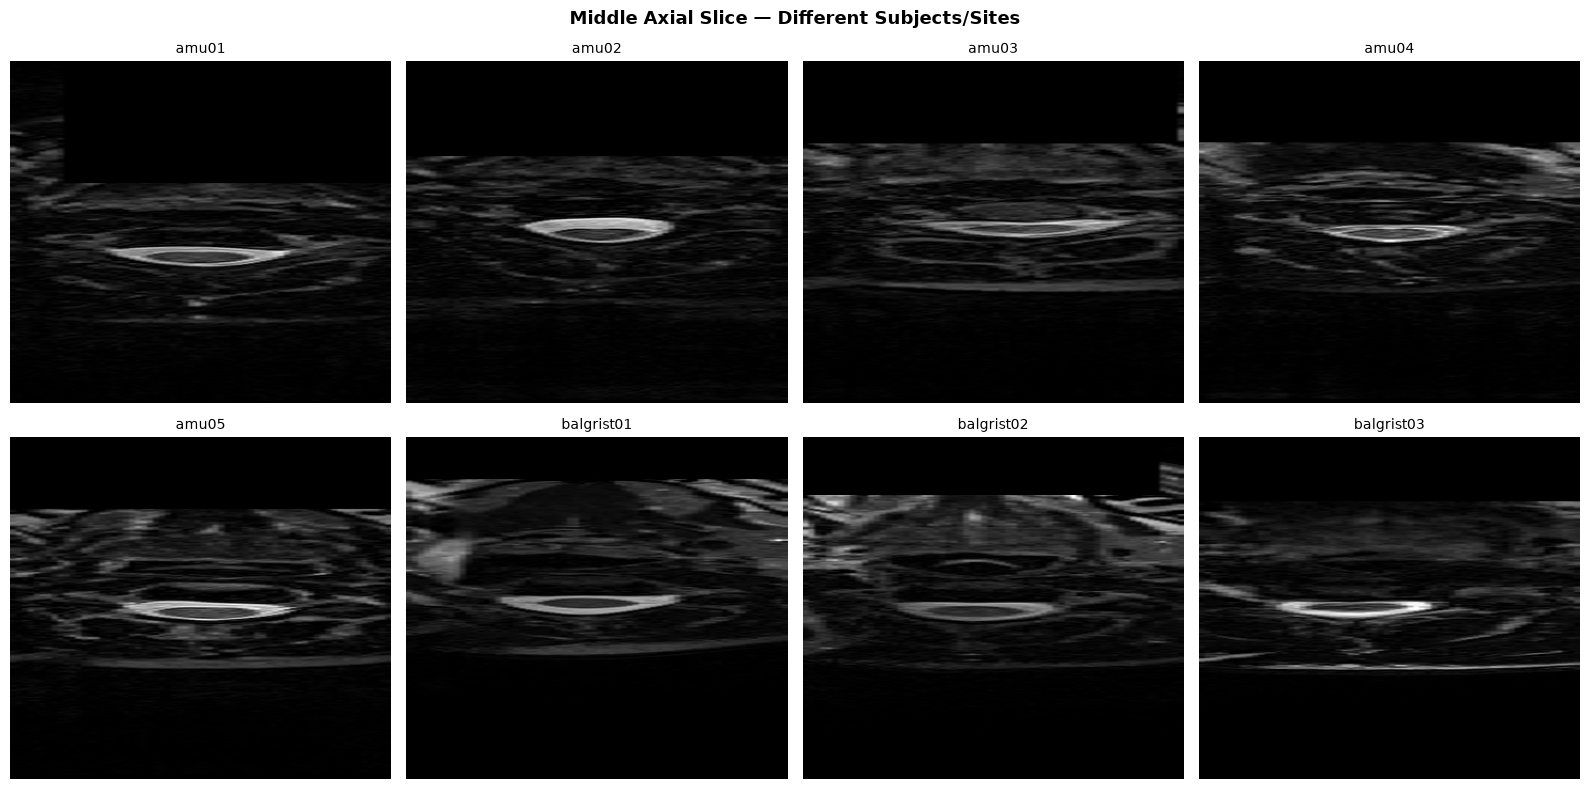

In [13]:
# Show middle axial slice from each subject
n = min(len(available), 8)
if n > 0:
    fig, axes = plt.subplots(2, n // 2 or 1, figsize=(4 * (n // 2 or 1), 8))
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flat
    
    for ax, sub in zip(axes, available[:n]):
        img = nib.load(str(sub['image_path']))
        data = np.asarray(img.dataobj).astype(np.float32)
        mid = data.shape[2] // 2
        ax.imshow(data[:, :, mid].T, cmap='gray', origin='lower', aspect='auto')
        ax.set_title(sub['id'].replace('sub-', ''), fontsize=10)
        ax.axis('off')
    
    plt.suptitle('Middle Axial Slice — Different Subjects/Sites', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No subjects with real data available.")

## Summary

**Key observations:**
- T2w spine volumes are typically ~300-600 slices along the SI axis
- Voxel spacing varies by site/scanner (need resampling for consistency)
- Spinal cord is a TINY structure — occupies <1% of the volume
- This extreme class imbalance is why we need `RandCropByPosNegLabel` (patches centered on cord)
- Git-annex stubs must be resolved before training
- spine-generic has **canal** labels (TotalSpineSeg-derived) for all subjects — enabling CSF domain extraction

**Available labels in spine-generic derivatives:**
- `label-SC_seg` — spinal cord binary mask (**inner boundary** of SAS)
- `label-canal_seg` — spinal canal (**outer boundary** of SAS) 
- `label-spine_dseg` — full spine multi-label (TotalSpineSeg)
- `label-rootlets_dseg` — nerve rootlets C2-C8 (21 subjects)
- `label-discs_dlabel` — intervertebral disc labels

**For CFD pipeline:** CSF fluid domain = canal − cord − rootlets

**Next notebooks:**
- → Notebook 02 (`02_eda.ipynb`): Dataset-wide statistics
- → Notebook 03 (`03_preprocessing_transforms.ipynb`): MONAI transforms
- → Notebook 04 (`04_model_training.ipynb`): SegResNet training
- → **Notebook 05** (`05_cfd_pipeline_demo.ipynb`): CFD pipeline — Boolean CSF extraction, mesh export, Sass validation, flow waveforms